# Branch Testing
---

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## 1. MOT Master Control

In [2]:
from pytweezer.experiment.motmaster_client import MotMasterClient
exp : MotMasterClient = MotMasterClient()

In [3]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(2)
#exp.start_motmaster_experiment()

{'ok': True,
 'command': 'interface_method',
 'method': 'set_iterations',
 'state': 'accepted'}

## 2. Hamamatsu Camera

In [4]:
from pytweezer.drivers.imagemX2 import ImagEMX2Camera

hamcam : ImagEMX2Camera = ImagEMX2Camera()

In [5]:
hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(1200)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

In [6]:
hamcam.close()

## 3. Phasemask Generation

In [15]:
import pytweezer.phasemask as pm

dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

W1 = np.ones((15, 15))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
#w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um
--- Target Generation ---
Grid: 15x15
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 2.53e-06 | Uniformity: 64.18% | Min/Max ratio: 0.081
Iteration 010 | Mean-Squared Error: 4.49e-08 | Uniformity: 95.23% | Min/Max ratio: 0.769
Iteration 020 | Mean-Squared Error: 6.04e-09 | Uniformity: 98.25% | Min/Max ratio: 0.907
Iteration 030 | Mean-Squared Error: 1.39e-09 | Uniformity: 99.16% | Min/Max ratio: 0.957
Iteration 040 | Mean-Squared Error: 8.77e-10 | Uniformity: 99.33% | Min/Max ratio: 0.964
Iteration 050 | Mean-Squared Error: 5.82e-10 | Uniformity: 99.46% | Min/Max ratio: 0.970
Iteration 060 | Mean-Squared Er

## 4. SLM

In [7]:
from pytweezer.drivers.slm import SLM

slm : SLM = SLM()

In [16]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

In [19]:
slm.close()

## 5. Analysis Functions

In [10]:
from pytweezer.analysis import analysis as pyt

texp = pyt.TweezerExperimentAnalysis(day='26',month='05May', year='2026')

---- 26/05May/202026 Tweezer Experiment Analysis Initialised ----


## 5. Test Experiment Run

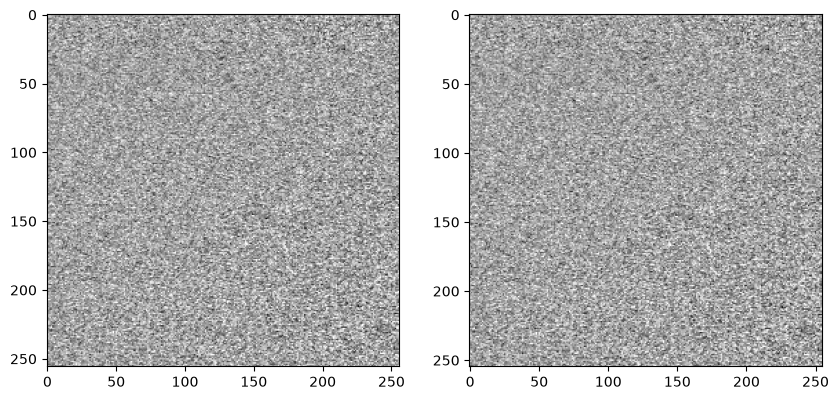

In [31]:
# Experiment and camera setup
n_iterations = 500
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment()

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = texp.tweezer_show_bg_subtracted(imgs1, imgs2, reg=[0, -1, 0, -1], cmap='gray', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
15x15 array detected.


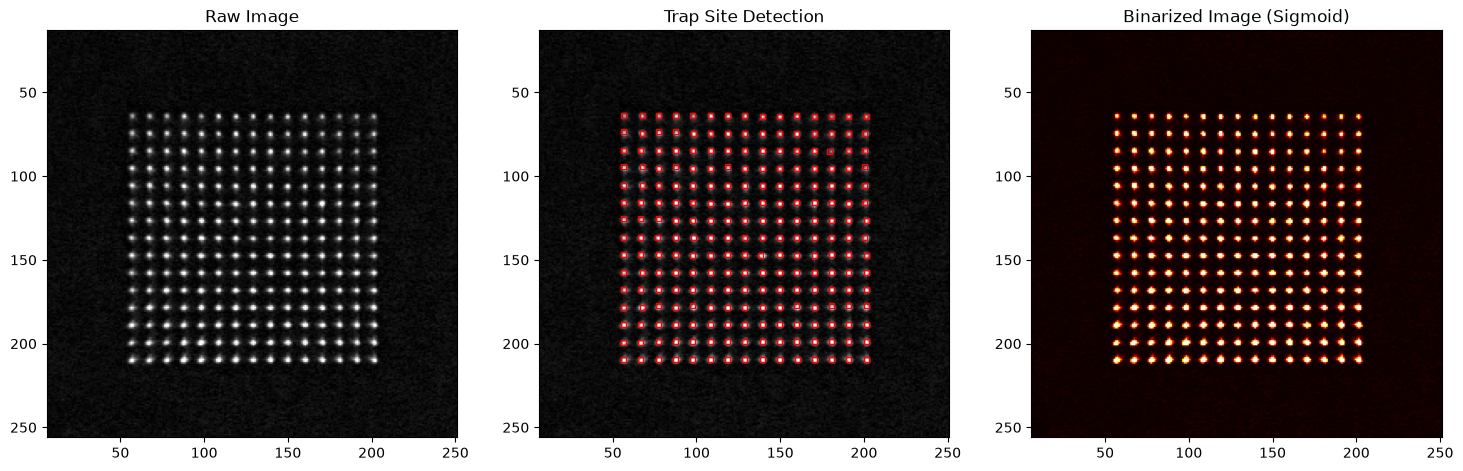

Trap (0, 0) Loading Probability : 37.00 %
Trap (0, 1) Loading Probability : 36.00 %
Trap (0, 2) Loading Probability : 38.00 %
Trap (0, 3) Loading Probability : 39.60 %
Trap (0, 4) Loading Probability : 26.40 %
Trap (0, 5) Loading Probability : 41.00 %
Trap (0, 6) Loading Probability : 40.60 %
Trap (0, 7) Loading Probability : 33.40 %
Trap (0, 8) Loading Probability : 34.60 %
Trap (0, 9) Loading Probability : 32.60 %
Trap (0, 10) Loading Probability : 36.00 %
Trap (0, 11) Loading Probability : 33.20 %
Trap (0, 12) Loading Probability : 32.80 %
Trap (0, 13) Loading Probability : 36.40 %
Trap (0, 14) Loading Probability : 42.60 %
Trap (1, 0) Loading Probability : 42.40 %
Trap (1, 1) Loading Probability : 45.40 %
Trap (1, 2) Loading Probability : 40.60 %
Trap (1, 3) Loading Probability : 37.40 %
Trap (1, 4) Loading Probability : 36.80 %
Trap (1, 5) Loading Probability : 36.20 %
Trap (1, 6) Loading Probability : 38.20 %
Trap (1, 7) Loading Probability : 38.80 %
Trap (1, 8) Loading Probabili

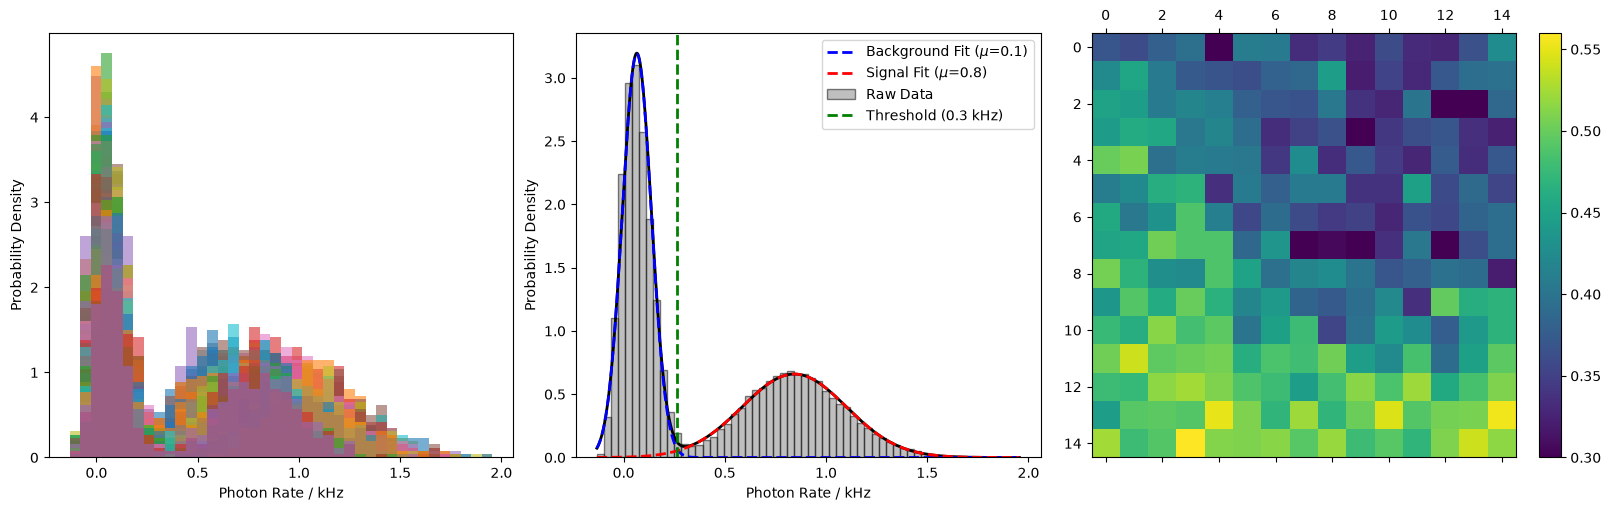

In [19]:
array_shape = [15, 15]
window = 3
feature_size = 10

filtered_img_average = pyt.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions, detection_threshold = pyt.detect_trap_sites(filtered_img_average, array_shape, detection_step=100)
pyt.visualize_results(filtered_img_average, grid_positions, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [pyt.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold, fidelity = texp.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)

In [32]:
# Save all images in imgs1 to the 'Image Data\100ms expo images' directory with filenames 'image_0001.tif', 'image_0002.tif', etc.
import os
import tifffile as tiff

output_dir = 'Image Data\\100ms dark images'
os.makedirs(output_dir, exist_ok=True)

for i, img in enumerate(imgs1):
    filename = f'image_{i+1:04d}.tif'
    filepath = os.path.join(output_dir, filename)
    tiff.imwrite(filepath, img)

## 6. Thor Cameras

In [9]:
from pytweezer.drivers.thorcam import ThorCamera

motcam : ThorCamera = ThorCamera(id="motcam")
tweezercam : ThorCamera = ThorCamera(id="tweezercam")

In [18]:
motcam.close()
tweezercam.close()

In [10]:
tweezercam.set_exposure_time(0.000001)
tweezercam.set_trigger_source("int")

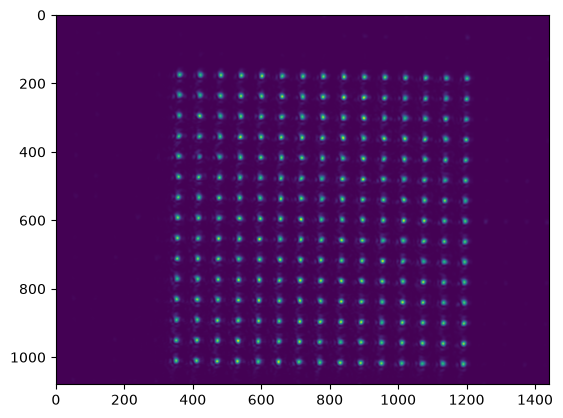

In [17]:
tweezercam.setup_acquisition(nframes=10)
tweezercam.start_acquisition()
imgs = tweezercam.acquire_n_frames(nframes=10)
img_mean = np.mean(imgs, axis=0)
plt.imshow(img_mean, cmap='viridis')

In [7]:
motcam.set_trigger_source("bulb")
motcam.set_roi(650, 600, 280, 600)

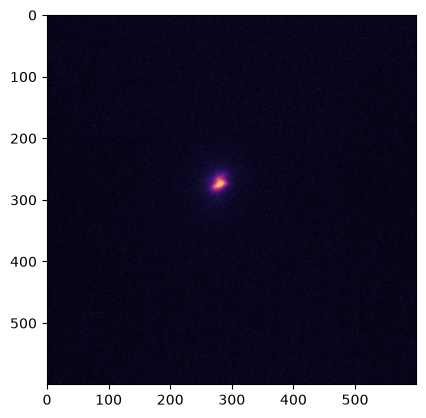

In [8]:
n_it = 10
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_it)
motcam.setup_acquisition(nframes=n_it)

motcam.start_acquisition()
exp.start_motmaster_experiment()
imgs = motcam.acquire_n_frames(nframes=n_it)

img_mean = np.mean(imgs, axis=0)
plt.imshow(img_mean, cmap='magma')

---